In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [48]:
df = pd.read_csv('letterdata.csv')

In [49]:
X = df.drop('letter', axis=1)
y = df['letter']

In [50]:
df.head()

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [51]:
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (20000, 16)
Shape of y: (20000,)


In [52]:
print("Number of Samples in Each Class:")
print(y.value_counts())

Number of Samples in Each Class:
letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64


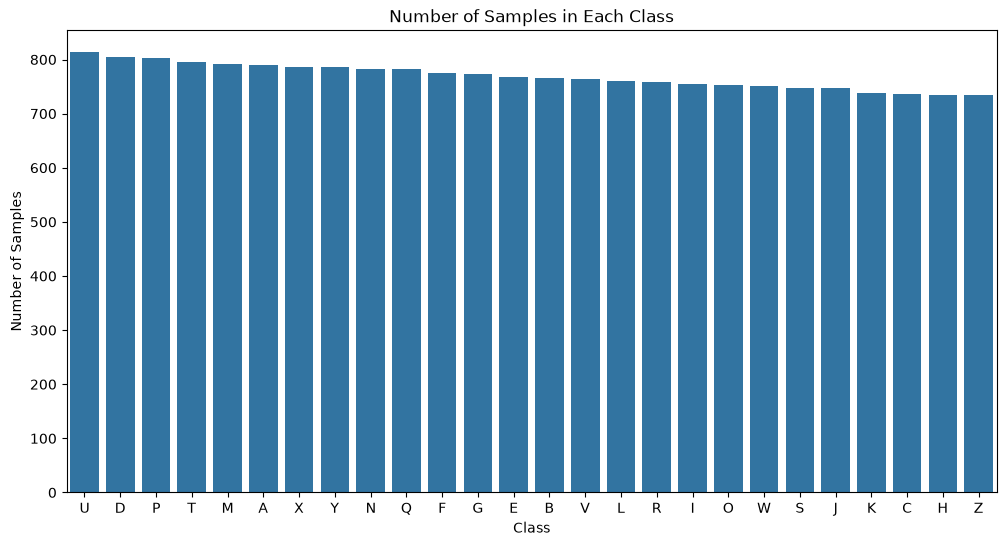

In [53]:
plt.figure(figsize=(12, 6))

sns.countplot(
    x=y,
    order=y.value_counts().index
)

plt.title("Number of Samples in Each Class")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (16000, 16)
Testing Features Shape: (4000, 16)
Training Target Shape: (16000,)
Testing Target Shape: (4000,)


In [55]:
svm_lr = SVC(kernel='linear')
svm_lr.fit(X_train, y_train)
print("Linear SVM Model Training Completed.")

Linear SVM Model Training Completed.


In [56]:
y_pred_lr = svm_lr.predict(X_test)

print("Predicted Values:")
print(y_pred_lr)

Predicted Values:
['A' 'H' 'S' ... 'L' 'R' 'L']


In [57]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Linear SVM Accuracy:", accuracy_lr)
print("Linear SVM Accuracy: {:.2f}%".format(accuracy_lr * 100))

Linear SVM Accuracy: 0.8505
Linear SVM Accuracy: 85.05%


In [58]:
SVC()
SVC(kernel='rbf')

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
svm_default = SVC()

svm_default.fit(X_train, y_train)

y_pred_default = svm_default.predict(X_test)

accuracy_default = accuracy_score(
    y_test,
    y_pred_default
)

print("Default SVM Accuracy:", accuracy_default)
print(
    "Default SVM Accuracy: {:.2f}%".format(
        accuracy_default * 100
    )
)

Default SVM Accuracy: 0.928
Default SVM Accuracy: 92.80%


In [60]:
svm_poly = SVC(kernel='poly')

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

accuracy_poly = accuracy_score(
    y_test,
    y_pred_poly
)

print("Polynomial SVM Accuracy:", accuracy_poly)
print(
    "Polynomial SVM Accuracy: {:.2f}%".format(
        accuracy_poly * 100
    )
)



Polynomial SVM Accuracy: 0.949
Polynomial SVM Accuracy: 94.90%


In [61]:
svm_sigmoid = SVC(kernel='sigmoid')

svm_sigmoid.fit(X_train, y_train)

y_pred_sigmoid = svm_sigmoid.predict(X_test)

accuracy_sigmoid = accuracy_score(
    y_test,
    y_pred_sigmoid
)

print("Sigmoid SVM Accuracy:", accuracy_sigmoid)
print(
    "Sigmoid SVM Accuracy: {:.2f}%".format(
        accuracy_sigmoid * 100
    )
)

Sigmoid SVM Accuracy: 0.03575
Sigmoid SVM Accuracy: 3.57%
